In [17]:
import pickle

# Open the file in 'rb' (read binary) mode
with open('../../ros-ws/saved_data/20260512_231419/episode_0.pkl', 'rb') as f:
    data = pickle.load(f)

# Print the contents to see what's inside
print(data.keys())

for k in data.keys():
    if k != "joint_names":
        print(f"{k}: {len(data[k])}, shape: {data[k][0]}")

print(data['action'][0].shape)


dict_keys(['camera_K', 'T_world_camera', 'joint_names', 'img', 'depth', 'mask', 'q', 'qd', 'eff', 'ee_pos', 'ee_quat_wxyz', 'gripper_pos', 'action', 'obj_pose_4x4', 'obj_pose_4x4_world'])
camera_K: 3, shape: [323.27528212   0.         129.60440538]
T_world_camera: 4, shape: [-0.9934887   0.00741888  0.1136889  -0.8128    ]
img: 380, shape: [[[221 187  85]
  [218 187  92]
  [216 188  96]
  ...
  [ 53  40  13]
  [ 51  39  10]
  [ 52  40   9]]

 [[219 187  87]
  [217 186  92]
  [215 186  95]
  ...
  [ 54  41  18]
  [ 51  39  14]
  [ 51  40  14]]

 [[206 176  80]
  [197 167  70]
  [209 180  84]
  ...
  [ 50  39  17]
  [ 50  39  16]
  [ 49  39  15]]

 ...

 [[ 52  57  42]
  [ 53  57  42]
  [ 54  57  42]
  ...
  [ 65  68  48]
  [ 63  68  48]
  [ 61  67  48]]

 [[ 50  57  40]
  [ 50  55  40]
  [ 56  57  44]
  ...
  [ 68  68  50]
  [ 69  69  49]
  [ 68  68  47]]

 [[ 53  57  42]
  [ 51  56  42]
  [ 51  57  43]
  ...
  [ 65  68  49]
  [ 65  67  46]
  [ 67  67  45]]]
depth: 380, shape: [[0.913 0

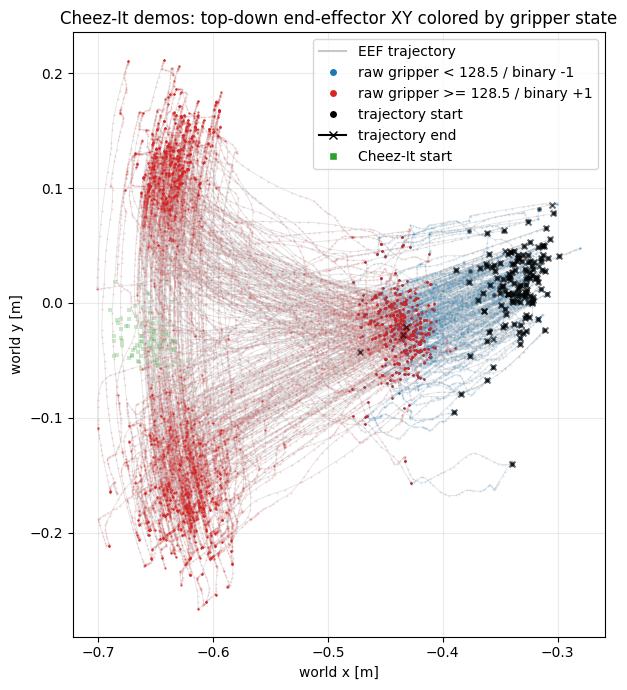

saved cheezit_eef_xy_gripper_topdown.png
demos: 137
start binary counts: -1=136, +1=1
end binary counts: -1=133, +1=4
first binary +1 index median/mean/max: 79.5 / 81.0 / 141
first binary +1 fraction median/mean/max: 0.190 / 0.194 / 0.312
demos with return to binary -1 after first +1: 133
Interpretation depends on hardware convention: in this HDF5, raw low values map to binary -1 and raw high values map to binary +1.


In [1]:
from pathlib import Path

import h5py
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

hdf5_path = Path('/home/moritz/src/guided-diffusion/data/real_world/cheezit_pouring.hdf5')
out_path = Path('cheezit_eef_xy_gripper_topdown.png')
midpoint = 128.5

fig, ax = plt.subplots(figsize=(8, 7))
stats = []

with h5py.File(hdf5_path, 'r') as f:
    demos = sorted(f['data'].keys(), key=lambda name: int(name.split('_')[1]))

    for demo in demos:
        group = f['data'][demo]
        xy = group['obs/eef_pos'][:, :2]
        obj_xy = group['obs/cheezit_pos'][:, :2]
        raw_gripper = group['obs/gripper_width'][:, 0]
        binary_gripper = group['obs/gripper_binary'][:, 0]
        raw_low = raw_gripper < midpoint

        ax.plot(xy[:, 0], xy[:, 1], color='0.78', linewidth=0.6, alpha=0.5, zorder=1)
        ax.scatter(xy[raw_low, 0], xy[raw_low, 1], s=2, color='tab:blue', alpha=0.18, linewidths=0, zorder=2)
        ax.scatter(xy[~raw_low, 0], xy[~raw_low, 1], s=2, color='tab:red', alpha=0.18, linewidths=0, zorder=3)
        ax.scatter(xy[0, 0], xy[0, 1], s=14, color='black', marker='o', alpha=0.45, linewidths=0, zorder=4)
        ax.scatter(xy[-1, 0], xy[-1, 1], s=18, color='black', marker='x', alpha=0.55, zorder=4)
        ax.scatter(obj_xy[0, 0], obj_xy[0, 1], s=10, color='tab:green', marker='s', alpha=0.25, linewidths=0, zorder=0)

        close_inds = np.flatnonzero(binary_gripper > 0)
        first_close = int(close_inds[0]) if len(close_inds) else None
        reopen = None
        if first_close is not None:
            reopen_inds = np.flatnonzero(binary_gripper[first_close + 1:] < 0)
            if len(reopen_inds):
                reopen = int(reopen_inds[0] + first_close + 1)
        stats.append((demo, len(binary_gripper), binary_gripper[0], binary_gripper[-1], first_close, reopen))

ax.set_title('Cheez-It demos: top-down end-effector XY colored by gripper state')
ax.set_xlabel('world x [m]')
ax.set_ylabel('world y [m]')
ax.set_aspect('equal', adjustable='box')
ax.grid(True, alpha=0.25)
ax.legend(handles=[
    Line2D([0], [0], color='0.78', lw=1.5, label='EEF trajectory'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=6, label='raw gripper < 128.5 / binary -1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:red', markersize=6, label='raw gripper >= 128.5 / binary +1'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=6, label='trajectory start'),
    Line2D([0], [0], marker='x', color='black', markersize=6, label='trajectory end'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='tab:green', markersize=6, label='Cheez-It start'),
], loc='best')
fig.tight_layout()
fig.savefig(out_path, dpi=200)
plt.show()

first_closes = np.array([s[4] if s[4] is not None else np.nan for s in stats], dtype=float)
reopens = np.array([s[5] if s[5] is not None else np.nan for s in stats], dtype=float)
lengths = np.array([s[1] for s in stats], dtype=float)
starts = np.array([s[2] for s in stats], dtype=float)
ends = np.array([s[3] for s in stats], dtype=float)

print(f'saved {out_path}')
print(f'demos: {len(stats)}')
print(f'start binary counts: -1={(starts == -1).sum()}, +1={(starts == 1).sum()}')
print(f'end binary counts: -1={(ends == -1).sum()}, +1={(ends == 1).sum()}')
print(f'first binary +1 index median/mean/max: {np.nanmedian(first_closes):.1f} / {np.nanmean(first_closes):.1f} / {np.nanmax(first_closes):.0f}')
print(f'first binary +1 fraction median/mean/max: {np.nanmedian(first_closes / lengths):.3f} / {np.nanmean(first_closes / lengths):.3f} / {np.nanmax(first_closes / lengths):.3f}')
print(f'demos with return to binary -1 after first +1: {np.isfinite(reopens).sum()}')
print('Interpretation depends on hardware convention: in this HDF5, raw low values map to binary -1 and raw high values map to binary +1.')
